In [2]:
import sys
from pathlib import Path

sys.path.insert(0, '..')

from utils.models import CNNLSTM
from utils.preprocessing import normalize_label_name, load_and_preprocess_data
from utils.evaluation import (
    load_and_evaluate_rf_model,
    load_and_evaluate_cnnlstm_model,
)
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

## Preprocess data

In [3]:
df_cicids2017 = load_and_preprocess_data("../data/CICIDS2017/wednesday_labeled.tsv")
df_ciciot2023 = load_and_preprocess_data("../data/CICIoT2023/ciciot2023_labeled_conn.tsv")
dataframes = [df_cicids2017, df_ciciot2023]

In [4]:
for df in dataframes:
    for col in [
        "duration",
        "orig_bytes",
        "resp_bytes",
        "missed_bytes",
        "orig_pkts",
        "orig_ip_bytes",
        "resp_pkts",
        "resp_ip_bytes",
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

In [5]:
label_column = "label"

df_cicids2017 = df_cicids2017[df_cicids2017["label"].isin(["DOS_HTTP_FLOOD"] + ["BENIGN"])]
df_ciciot2023 = df_ciciot2023[df_ciciot2023["label"].isin(["DOS_HTTP_FLOOD"] + ["BENIGN"])]

X_cicids = df_cicids2017.drop(columns=[label_column])
y_cicids = df_cicids2017[label_column]

X_ciciot = df_ciciot2023.drop(columns=[label_column])
y_ciciot = df_ciciot2023[label_column]

print("CICIDS test shape:", X_cicids.shape)
print("CICIoT test shape:", X_ciciot.shape)

CICIDS test shape: (481829, 22)
CICIoT test shape: (1850844, 22)


## Load Models and evaluate

Evaluation for CICIDS2017-trained RF on CICIoT2023:

=== CICIDS2017-trained RF on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1849    1.0000    0.3121    342255
DOS_HTTP_FLOOD     1.0000    0.0000    0.0000   1508589

      accuracy                         0.1849   1850844
     macro avg     0.5925    0.5000    0.1561   1850844
  weighted avg     0.8493    0.1849    0.0577   1850844


=== Per-Label Accuracy ===

BENIGN: 1.0000
DOS_HTTP_FLOOD: 0.0000


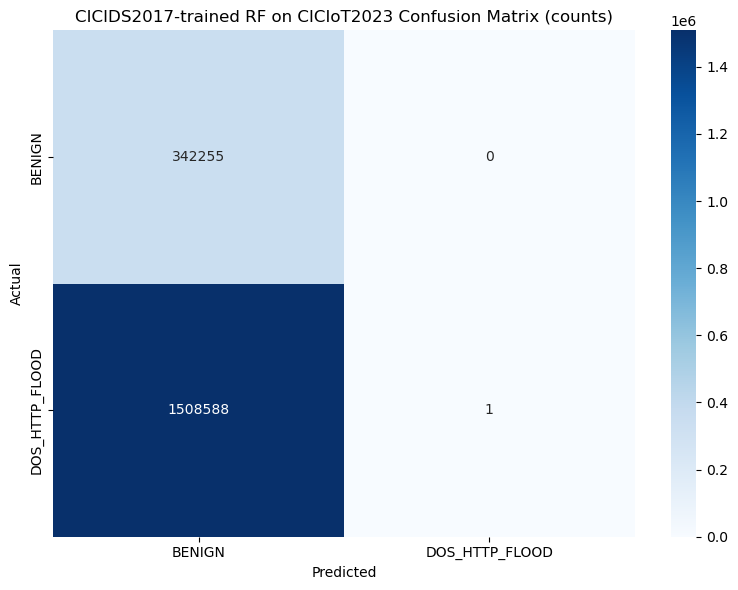

In [6]:
# Test CICIDS2017-trained RF model on CICIoT2023
load_and_evaluate_rf_model(
    joblib_path="models/random_forest_cicids2017.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained RF on CICIoT2023"
)

Evaluation for CICIoT2023-trained RF on CICIDS2017:

=== CICIoT2023-trained RF on CICIDS2017 Classification Report ===



c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

                precision    recall  f1-score   support

        BENIGN     0.0000    0.0000    0.0000    327060
DOS_HTTP_FLOOD     0.3212    1.0000    0.4862    154769

      accuracy                         0.3212    481829
     macro avg     0.1606    0.5000    0.2431    481829
  weighted avg     0.1032    0.3212    0.1562    481829


=== Per-Label Accuracy ===

BENIGN: 0.0000
DOS_HTTP_FLOOD: 1.0000


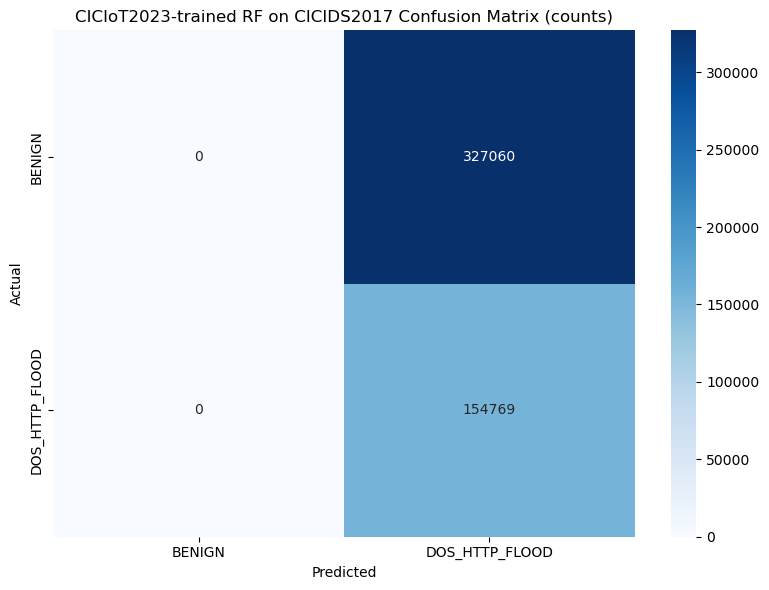

In [7]:
# Test CICIoT2023-trained RF model on CICIDS2017
load_and_evaluate_rf_model(
    joblib_path="models/random_forest_ciciot2023.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained RF on CICIDS2017"
)

Evaluation for CICIoT2023-trained CNN-LSTM on CICIDS2017:

=== CICIoT2023-trained CNN-LSTM on CICIDS2017 Classification Report ===



c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

                precision    recall  f1-score   support

        BENIGN     0.0000    0.0000    0.0000    327060
DOS_HTTP_FLOOD     0.3212    1.0000    0.4862    154769

      accuracy                         0.3212    481829
     macro avg     0.1606    0.5000    0.2431    481829
  weighted avg     0.1032    0.3212    0.1562    481829


=== Per-Label Accuracy ===

BENIGN: 0.0000
DOS_HTTP_FLOOD: 1.0000


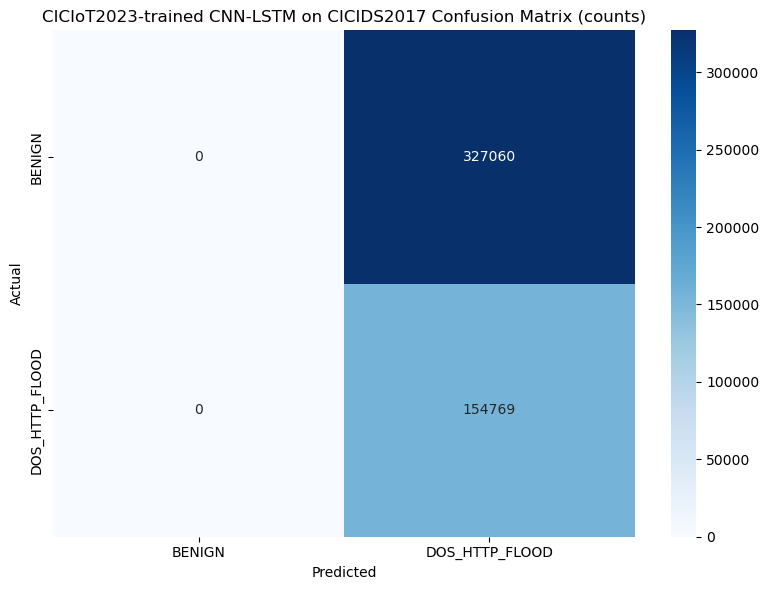

In [8]:
# Test CICIoT2023-trained CNN-LSTM model on CICIDS2017
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_ciciot2023.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained CNN-LSTM on CICIDS2017"
)

Evaluation for CICIDS2017-trained CNN-LSTM on CICIoT2023:

=== CICIDS2017-trained CNN-LSTM on CICIoT2023 Classification Report ===



c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

                precision    recall  f1-score   support

        BENIGN     0.1849    1.0000    0.3121    342255
DOS_HTTP_FLOOD     0.0000    0.0000    0.0000   1508589

      accuracy                         0.1849   1850844
     macro avg     0.0925    0.5000    0.1561   1850844
  weighted avg     0.0342    0.1849    0.0577   1850844


=== Per-Label Accuracy ===

BENIGN: 1.0000
DOS_HTTP_FLOOD: 0.0000


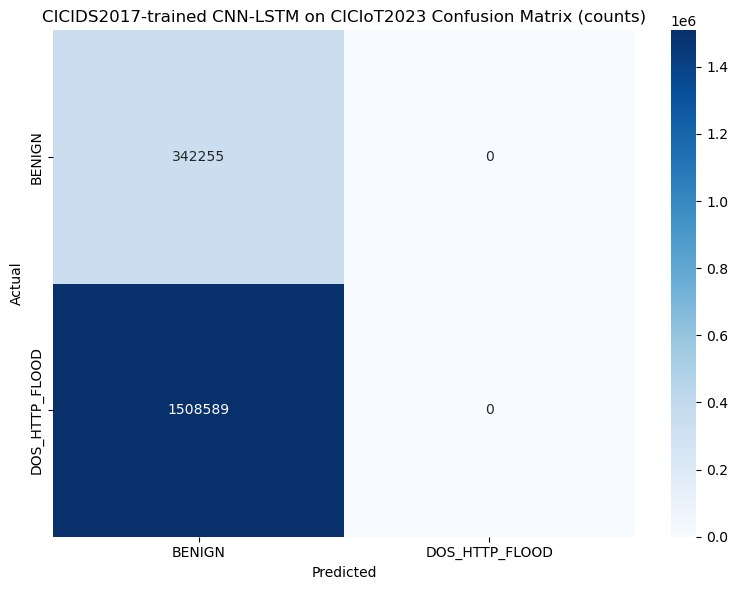

In [9]:
# Test CICIDS2017-trained CNN-LSTM model on CICIoT2023
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_cicids2017.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained CNN-LSTM on CICIoT2023"
)